In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import matplotlib.font_manager as fm

In [2]:
font_path = "/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Work Sans"
work_sans_title = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Bold.ttf", size=16)
work_sans_axis = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf", size=12)

In [3]:
df = pd.read_csv("/Users/anvi/Desktop/climate_science/GISS_Surface_Temperature_Analysis_v4/data/L_OTI/global/northern_mean.csv", skiprows=1)

In [4]:
print(f"Number of columns in df: {df.shape[1]}")
print(f"Number of rows in df: {df.shape[0]}")

Number of columns in df: 19
Number of rows in df: 147


In [5]:
df

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.37,-0.52,-0.24,-0.31,-0.07,-0.17,-0.20,-0.28,-.25,-.33,-.44,-.41,-.30,***,***,-0.21,-0.21,-.34
1,1881,-0.31,-0.23,-0.04,0.00,0.03,-0.34,0.07,-0.05,-.27,-.44,-.37,-.24,-.18,-.20,-.32,-0.01,-0.11,-.36
2,1882,0.26,0.20,0.02,-0.30,-0.24,-0.29,-0.28,-0.17,-.26,-.52,-.34,-.69,-.22,-.18,.07,-0.18,-0.25,-.38
3,1883,-0.58,-0.66,-0.16,-0.30,-0.25,-0.11,-0.06,-0.23,-.34,-.16,-.45,-.15,-.29,-.33,-.64,-0.23,-0.14,-.32
4,1884,-0.17,-0.11,-0.64,-0.58,-0.36,-0.42,-0.41,-0.52,-.45,-.45,-.58,-.47,-.43,-.40,-.14,-0.53,-0.45,-.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2022,1.24,1.16,1.41,1.09,1.03,1.13,1.07,1.17,1.15,1.32,1.10,1.07,1.16,1.17,1.19,1.18,1.12,1.19
143,2023,1.29,1.28,1.64,1.01,1.13,1.20,1.45,1.57,1.68,1.88,1.96,1.85,1.50,1.43,1.21,1.26,1.41,1.84
144,2024,1.67,1.93,1.78,1.79,1.45,1.54,1.42,1.43,1.56,1.75,1.89,1.71,1.66,1.67,1.82,1.67,1.46,1.73
145,2025,1.85,1.63,1.84,1.60,1.22,1.20,1.23,1.29,1.41,1.49,1.68,1.42,1.49,1.51,1.73,1.56,1.24,1.53


---

J-D : calendar year average; from the first day of January to the last day of December

D-N : meteorological year average; from the first day of December to the last day of November

In [6]:
df.rename(columns={'Jan':'January', 'Feb':'February', 'Mar':'March', 'Apr':'April', 'May':'May', 'Jun':'June', 'Jul':'July', 'Aug':'August', 'Sep':'September', 'Oct':'October', 'Nov':'November', 'Dec':'December'}, inplace=True)

In [7]:
temp_columns = df.columns.drop('Year')

In [8]:
df[temp_columns] = df[temp_columns].apply(pd.to_numeric, errors='coerce') * 0.01

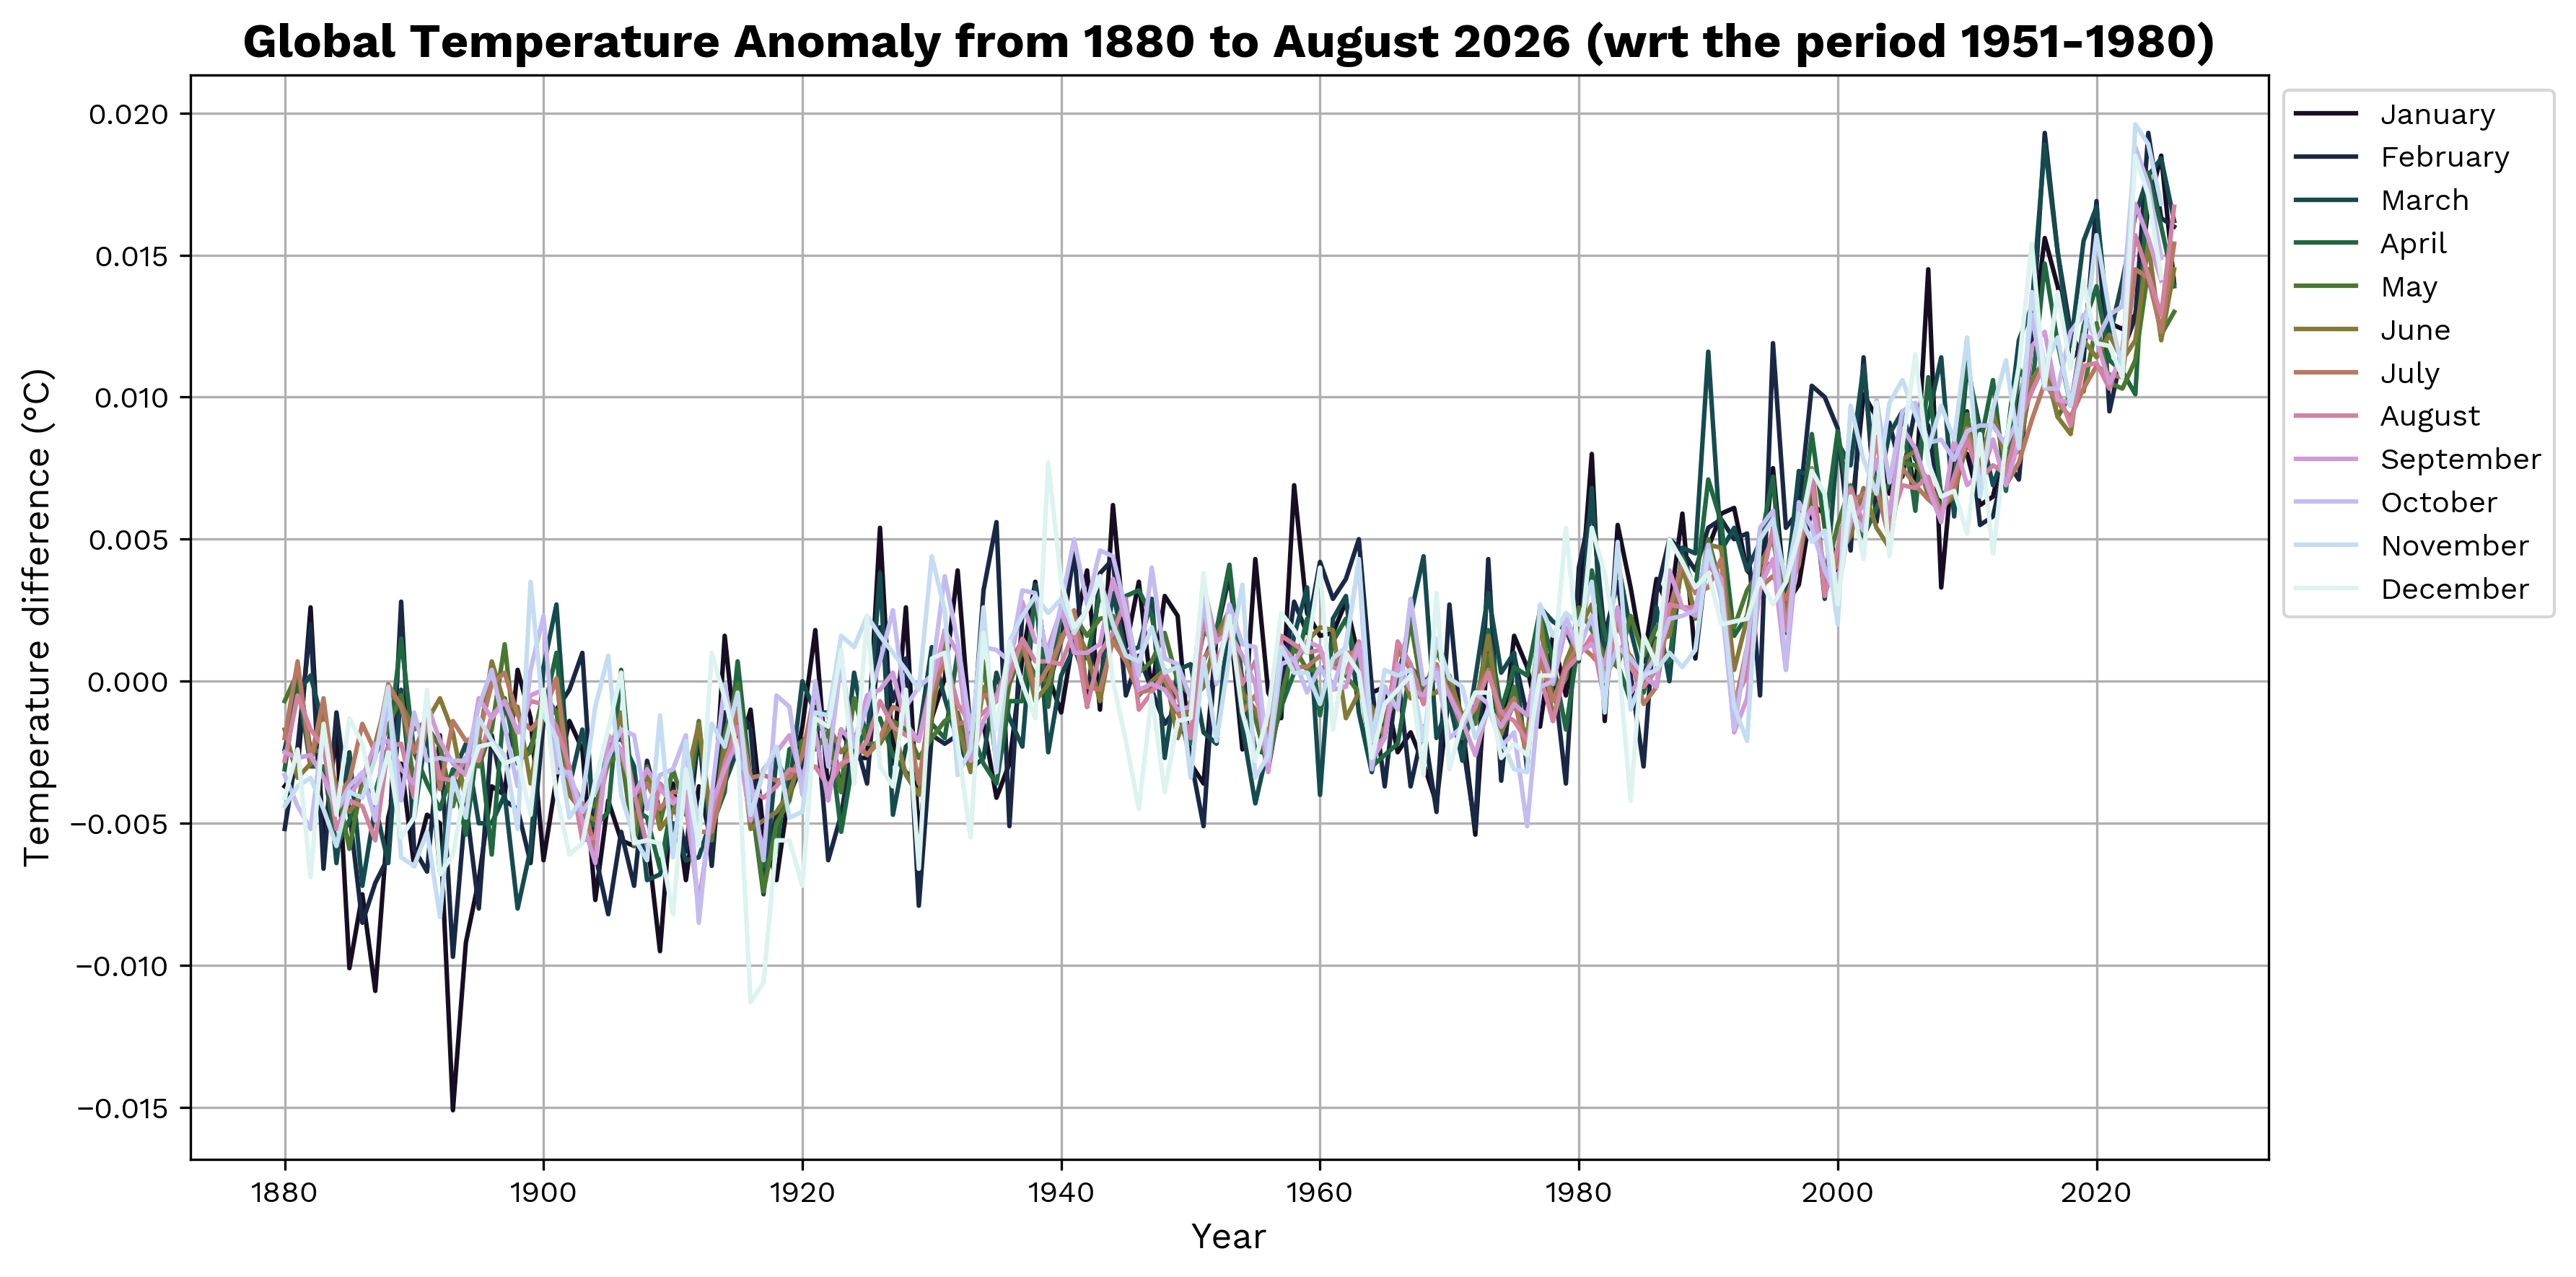

In [9]:
plt.figure(figsize=(12, 6), dpi=300)

monthly_columns = temp_columns[:12]

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("cubehelix", n_colors=len(monthly_columns))

#plotting the temperature data for each month
for col in monthly_columns:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.savefig('/Users/anvi/Desktop/climate_science/notebook/GISS/out/plots/Global_Temperature_Anomaly_1880-2026.png', dpi=1000, bbox_inches='tight')
plt.show()

In [10]:
plt.figure(figsize=(12, 6), dpi=1000)

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("magma", n_colors=len(temp_columns[12:14]))

#plotting the temperature data for each month
for col in temp_columns[12:14]:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
plt.figure(figsize=(12, 6), dpi=1000)

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("magma", n_colors=len(temp_columns[14:17:2]))

#plotting the temperature data for each month
for col in temp_columns[14:17:2]:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# transforming the months into rows; and inverting to have January at the top and December at the bottom
heatmap_data = df.set_index("Year")[monthly_columns].T.iloc[::-1]

In [13]:
plt.figure(figsize=(14, 6), dpi=1000)

ax = sns.heatmap(
        heatmap_data,
        cmap="RdYlBu_r",
        center=0,
        linewidths=0.1,
        xticklabels=4,
        cbar_kws={"label": "Temperature difference (°C)"}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.xlabel("Year", fontproperties=work_sans_axis)
plt.ylabel("Month", fontproperties=work_sans_axis)
plt.title(
    "Monthly Global Temperature Anomalies",
    fontproperties=work_sans_title
)
plt.tight_layout()
plt.savefig('/Users/anvi/Desktop/climate_science/notebook/GISS/out/heatmaps/Monthly_Global_Temperature_Anomalies.png', dpi=1000, bbox_inches='tight')
plt.show()